In [2]:
!git clone https://github.com/AleksandraJuchniewicz/Analiza-danych.git

'git' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
%cd Analiza-danych
!ls

[WinError 2] Nie można odnaleźć określonego pliku: 'Analiza-danych'
c:\Users\ksepk\Documents\GitHub\Analiza-danych


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

df_d = pd.read_csv("bdl_data_dewastacja_.csv")
df_poz=pd.read_csv("bdl_data_pozar_.csv")
df_gaz=pd.read_csv("bdl_data_Zangaz_.csv")
df_pyl=pd.read_csv("bdl_data_Zanpyl_.csv")
df_zat=pd.read_csv("bdl_data_zatrudnienie_.csv")
df_il=pd.read_csv("bdl_datailosc_2024_.csv")
df_war=pd.read_csv("bdl_datawartosc_2024_.csv")
df_las=pd.read_csv("bdl_powlas_2024_.csv")
df_lasch=pd.read_csv("bdl_powlaschro_2024_.csv")


In [6]:
dfs = [df_d, df_poz, df_gaz, df_pyl, df_zat, df_il, df_war, df_las, df_lasch]
new_names = [
    "Dewastacja",
    "Pozary",
    "Za_gaz",
    "Za-pyl",
    "Zatrudnienie",
    "Ilosc",
    "Wartosc",
    "P_lasy",
    "P_lasy_ch"
]
for df, new_name in zip(dfs, new_names):
    df.rename(columns={"Value": new_name}, inplace=True)
for i, df in enumerate(dfs, start=1):
    print(f"df{i}:", df.columns.tolist())



df1: ['Region', 'Year', 'Dewastacja']
df2: ['Region', 'Year', 'Pozary']
df3: ['Region', 'Year', 'Za_gaz']
df4: ['Region', 'Year', 'Za-pyl']
df5: ['Region', 'Year', 'Zatrudnienie']
df6: ['Region', 'Year', 'Ilosc']
df7: ['Region', 'Year', 'Wartosc']
df8: ['Region', 'Year', 'P_lasy']
df9: ['Region', 'Year', 'P_lasy_ch']


In [7]:
for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {df['Year'].min()}–{df['Year'].max()}")



df1: 2005–2020
df2: 2009–2024
df3: 1998–2024
df4: 1996–2024
df5: 2010–2024
df6: 2009–2024
df7: 2009–2024
df8: 1998–2024
df9: 1998–2024


In [8]:
for i in range(len(dfs)):
    dfs[i] = dfs[i].loc[
        (dfs[i]["Year"] >= 2016) &
        (dfs[i]["Year"] <= 2020)
    ].copy()

for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {sorted(df['Year'].unique())}")


df1: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df2: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df3: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df4: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df5: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df6: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df7: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df8: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df9: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [41]:
from functools import reduce
import numpy as np
from sklearn.preprocessing import StandardScaler
df_all = reduce(
    lambda left, right: left.merge(
        right,
        on=["Region", "Year"],
        how="inner"
    ),
    dfs
)
print(df_all.shape)
print(df_all.head())

df_stand = df_all.drop(columns=["Region", "Year"])
data_norm_3 = (df_stand - df_stand.mean(axis=0,skipna=True,numeric_only=True)) / df_stand.std(axis=0,skipna=True,numeric_only=True,ddof=1)
data_norm_z = df_all[["Region", "Year"]].merge(data_norm_3, left_index=True, right_index=True)
def vec_norm(df_all, axis=0):
    return df_all / np.sqrt(np.nansum(df_all**2, axis=axis))

data_norm_1 = df_stand.apply(vec_norm, axis=0)
data_norm_vec = df_all[["Region", "Year"]].merge(data_norm_1, left_index=True, right_index=True)
def pos_norm(x):
    return (x - np.nanmedian(x)) / (
        np.nanpercentile(x, 75) - np.nanpercentile(x, 25)
    )
data_norm_2 = df_stand.apply(pos_norm)
data_norm_pos = df_all[["Region", "Year"]].merge(data_norm_2, left_index=True, right_index=True)

print(data_norm_z.head())
print(data_norm_vec.head())
print(data_norm_pos.head())

(80, 11)
        Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
0  MAŁOPOLSKIE  2016        54.4    97.0  10059451.0  2067.0          50.4   
1  MAŁOPOLSKIE  2017        53.7   116.0  10927841.0  2057.0          51.3   
2  MAŁOPOLSKIE  2018        52.7   236.0  10483040.0  1841.0          52.3   
3  MAŁOPOLSKIE  2019        54.5   190.0   8996236.0  1635.0          53.5   
4  MAŁOPOLSKIE  2020        56.9   176.0   7002044.0  1088.0          53.5   

   Ilosc  Wartosc     P_lasy  P_lasy_ch  
0   22.0    469.0  202140.16   18043.51  
1   16.0    196.7  202078.00   18112.17  
2    9.0    101.0  201366.39   18143.25  
3   27.0    231.9  201241.09   18197.84  
4   18.0    198.6  201200.81   18238.77  
        Region  Year  Dewastacja    Pozary    Za_gaz    Za-pyl  Zatrudnienie  \
0  MAŁOPOLSKIE  2016    0.431116 -0.784158 -0.230213  0.075630     -0.901115   
1  MAŁOPOLSKIE  2017    0.125901 -0.738746 -0.156790  0.069387     -0.585550   
2  MAŁOPOLSKIE  2018   -0.3101

In [10]:
#braki
df_all.isna().sum()
#duikaty
df_all.duplicated(["Region", "Year"]).sum()


np.int64(0)

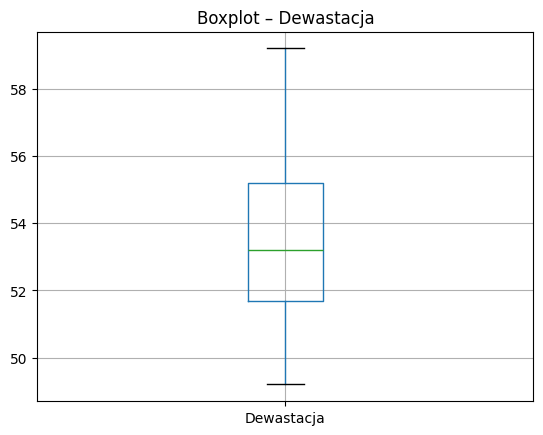

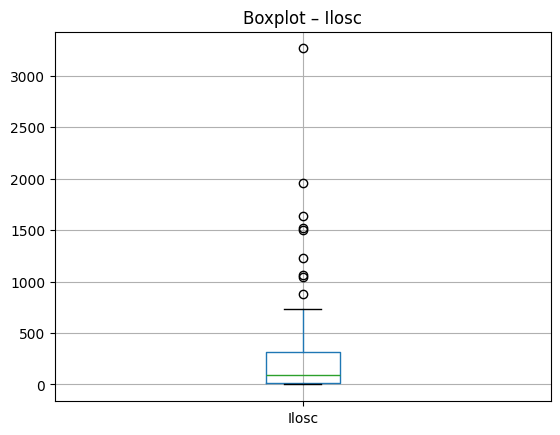

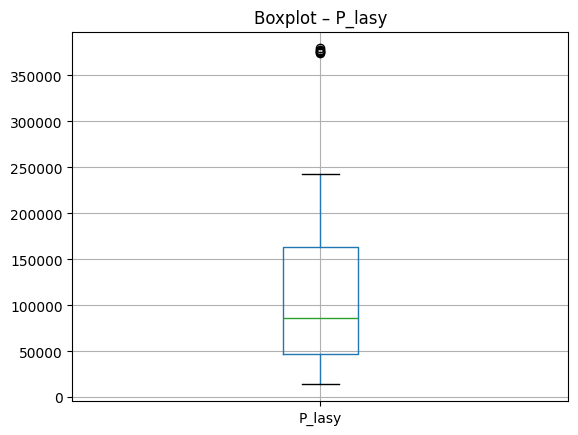

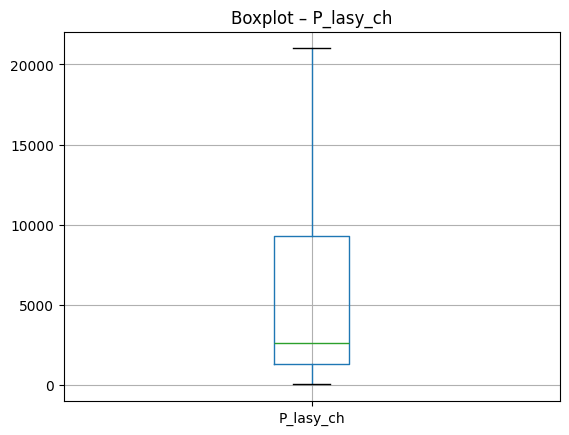

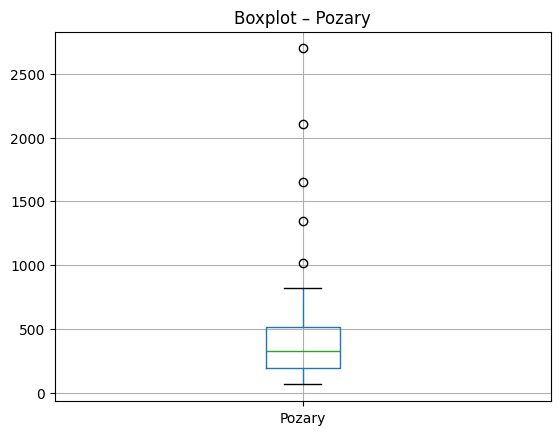

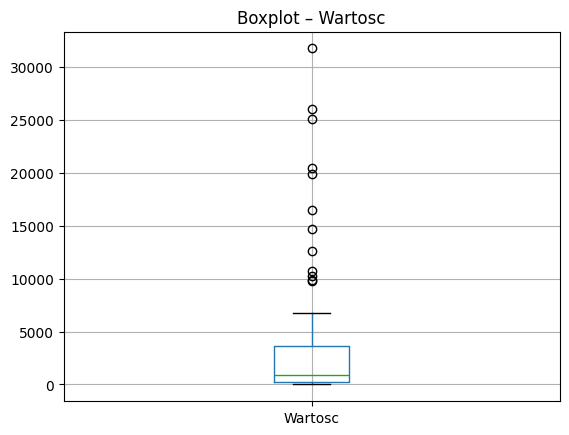

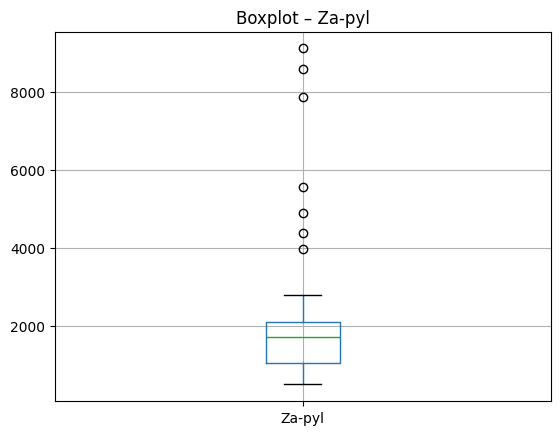

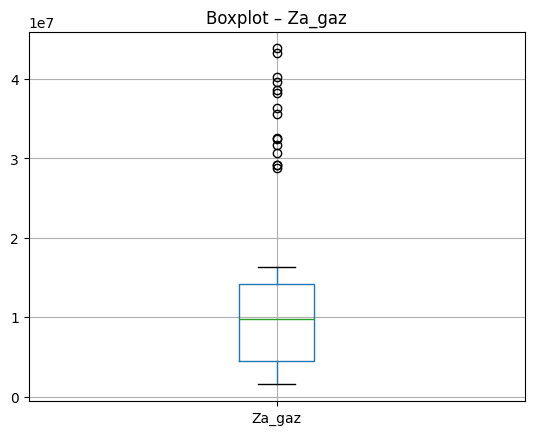

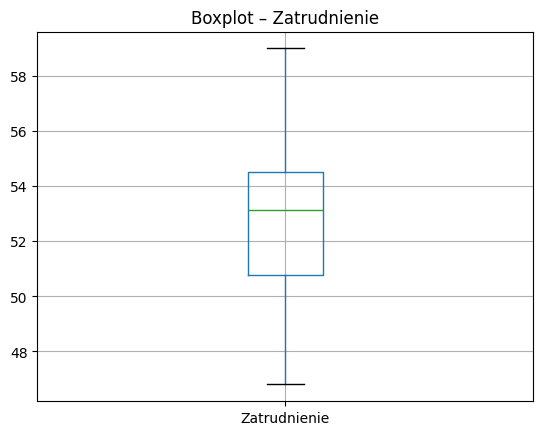

In [11]:
cols_to_plot = df_all.columns.difference(["Region", "Year"])

import matplotlib.pyplot as plt

for col in cols_to_plot:
    plt.figure()
    df_all.boxplot(column=col)
    plt.title(f"Boxplot – {col}")
    plt.show()


In [12]:
def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)].copy()
    outliers["Zmienna"] = col
    outliers["Dolna_granica"] = lower
    outliers["Gorna_granica"] = upper

    return outliers


In [13]:
outlier_list = []

for col in cols_to_plot:
    out = iqr_outliers(df_all, col)
    outlier_list.append(out)

outliers_df = pd.concat(outlier_list, ignore_index=True)

outliers_df = outliers_df[
    ["Zmienna", "Region", "Year", col]
]
outliers_df.groupby("Zmienna").size()
print(outliers_df)



    Zmienna               Region  Year  Zatrudnienie
0     Ilosc             LUBUSKIE  2017          53.7
1     Ilosc             LUBUSKIE  2019          54.5
2     Ilosc        WIELKOPOLSKIE  2016          55.2
3     Ilosc        WIELKOPOLSKIE  2017          57.2
4     Ilosc        WIELKOPOLSKIE  2018          57.7
5     Ilosc        WIELKOPOLSKIE  2019          57.5
6     Ilosc            POMORSKIE  2016          54.6
7     Ilosc            POMORSKIE  2017          56.0
8     Ilosc            POMORSKIE  2019          58.1
9    P_lasy          MAZOWIECKIE  2016          56.2
10   P_lasy          MAZOWIECKIE  2017          57.2
11   P_lasy          MAZOWIECKIE  2018          58.4
12   P_lasy          MAZOWIECKIE  2019          59.0
13   P_lasy          MAZOWIECKIE  2020          58.6
14   Pozary          MAZOWIECKIE  2016          56.2
15   Pozary          MAZOWIECKIE  2017          57.2
16   Pozary          MAZOWIECKIE  2018          58.4
17   Pozary          MAZOWIECKIE  2019        

In [14]:
df_all.drop(columns="Year").describe()

,Dewastacja,Pozary,Za_gaz,Za-pyl,Zatrudnienie,Ilosc,Wartosc,P_lasy,P_lasy_ch
count,80.000000,80.000000,8.000000e+01,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,53.411250,425.087500,1.278226e+07,1945.850000,52.970000,299.050000,3805.297500,116858.864875,5577.767250
std,2.293469,418.394859,1.182737e+07,1601.886168,2.852021,538.047099,6545.550619,96412.072448,5735.863331
min,49.200000,63.000000,1.531405e+06,503.000000,46.800000,0.000000,0.000000,13991.000000,51.150000
25%,51.675000,194.750000,4.533884e+06,1048.000000,50.775000,18.000000,224.750000,47077.070000,1328.385000
50%,53.200000,325.000000,9.755750e+06,1713.000000,53.150000,92.500000,863.250000,86609.380000,2635.355000
75%,55.200000,515.250000,1.413255e+07,2093.250000,54.525000,312.250000,3674.525000,163622.735000,9300.225000
max,59.200000,2699.000000,4.383573e+07,9113.000000,59.000000,3264.000000,31711.900000,379481.590000,21005.560000


In [15]:
num=df_all.drop(columns=["Year"])
df_all_std=(num.mean(axis=0,skipna=True,numeric_only=True))/(num.std(axis=0,skipna=True,numeric_only=True))

In [16]:
print(df_all_std)

Dewastacja      23.288415
Pozary           1.015996
Za_gaz           1.080735
Za-pyl           1.214724
Zatrudnienie    18.572793
Ilosc            0.555806
Wartosc          0.581356
P_lasy           1.212077
P_lasy_ch        0.972437
dtype: float64


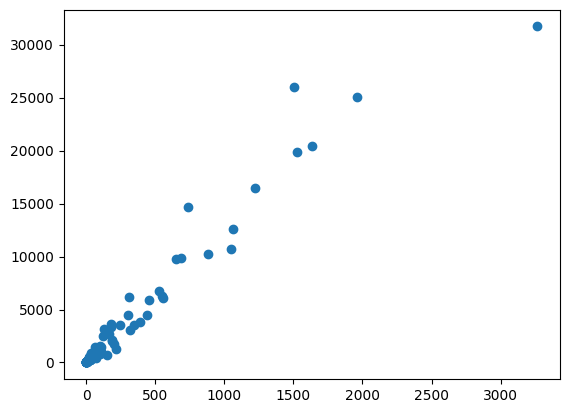

In [19]:
from matplotlib import pyplot as plt
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Wartosc'])
#plt.yscale('log') 
plt.show()

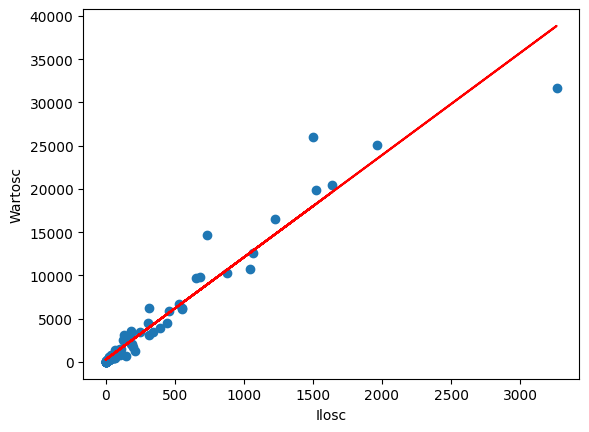

In [21]:
import numpy as np
np.corrcoef(df_all['Ilosc'], df_all['Wartosc'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Wartosc'])
x = df_all['Ilosc']
y = df_all['Wartosc']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit, color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Wartosc')
plt.show()

<Figure size 640x480 with 0 Axes>

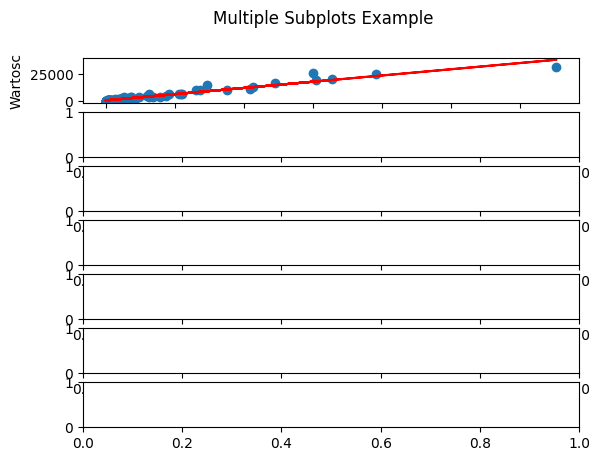

In [25]:
import numpy as np
np.corrcoef(df_all['Ilosc'], df_all['Wartosc'])
plt.clf()
fig, axs = plt.subplots(7)
fig.suptitle('Multiple Subplots Example')
axs[0].scatter(df_all['Ilosc'], df_all['Wartosc'])
x = df_all['Ilosc']
y = df_all['Wartosc']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

axs[0].plot(x, y_fit, color='red', label='Regression line')
axs[0].set_xlabel('Ilosc')
axs[0].set_ylabel('Wartosc')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\2890299507.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Dewastacja'], c= color_seq, cmap='viridis' )


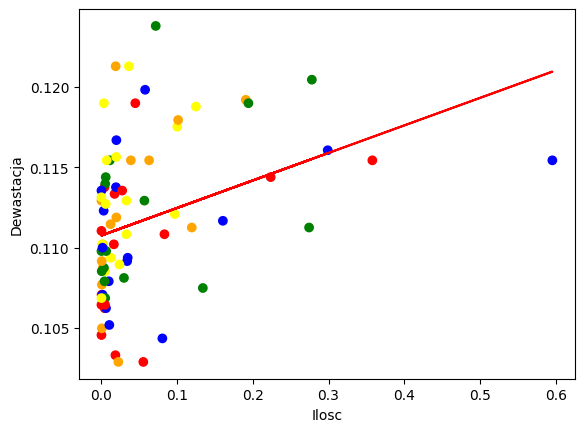

In [ ]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Ilosc'], data_norm_vec['Dewastacja'])
plt.clf()
plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Dewastacja'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Ilosc']
y = data_norm_vec['Dewastacja']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Dewastacja')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\492985731.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Dewastacja'], c= color_seq, cmap='viridis' )


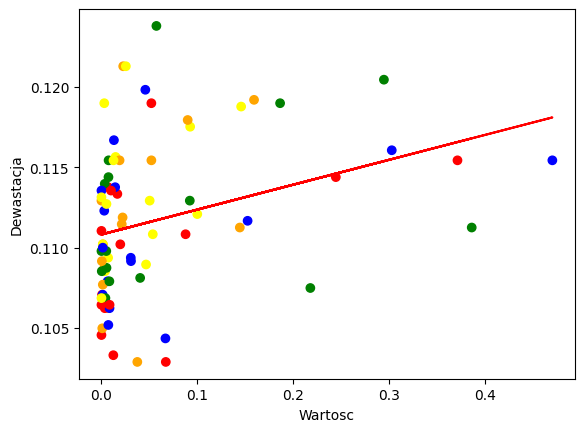

In [75]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Wartosc'], data_norm_vec['Dewastacja'])
plt.clf()
plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Dewastacja'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Wartosc']
y = data_norm_vec['Dewastacja']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Dewastacja')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\2041434505.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['P_lasy'], c= color_seq, cmap='viridis' )


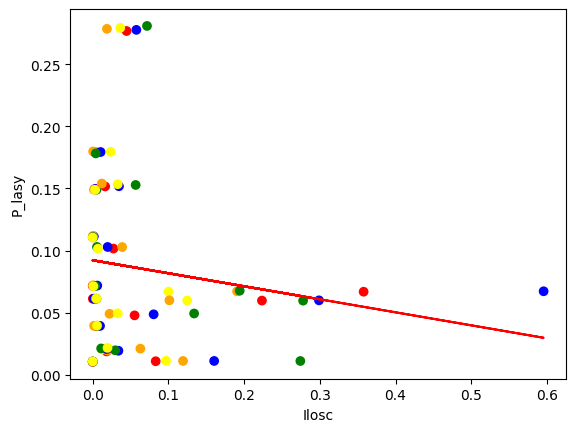

In [76]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Ilosc'], data_norm_vec['P_lasy'])
plt.clf()
plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['P_lasy'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Ilosc']
y = data_norm_vec['P_lasy']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('P_lasy')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\1770085782.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['P_lasy'], c= color_seq, cmap='viridis' )


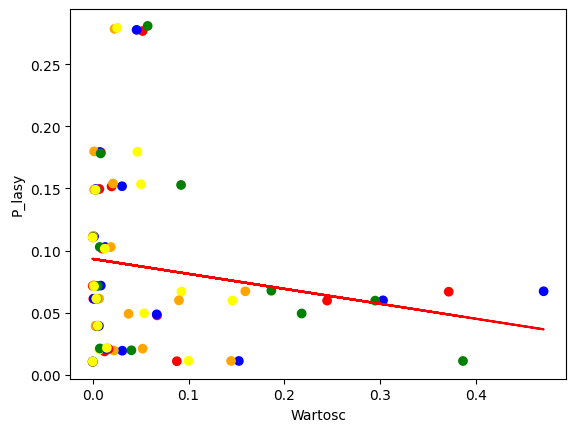

In [77]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Wartosc'], data_norm_vec['P_lasy'])
plt.clf()
plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['P_lasy'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Wartosc']
y = data_norm_vec['P_lasy']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('P_lasy')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\3973854701.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['P_lasy_ch'], c= color_seq, cmap='viridis' )


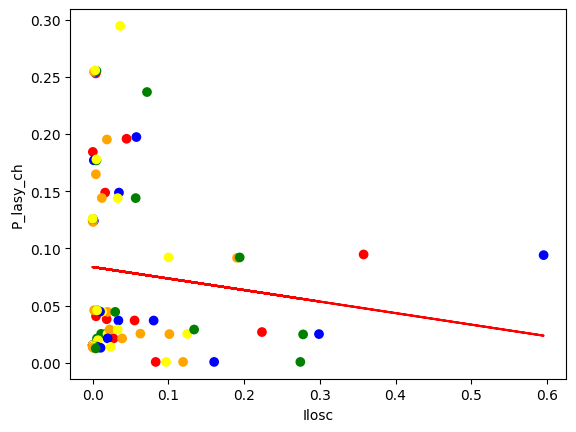

In [78]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Ilosc'], data_norm_vec['P_lasy_ch'])
plt.clf()
plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['P_lasy_ch'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Ilosc']
y = data_norm_vec['P_lasy_ch']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('P_lasy_ch')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\2629903444.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['P_lasy_ch'], c= color_seq, cmap='viridis' )


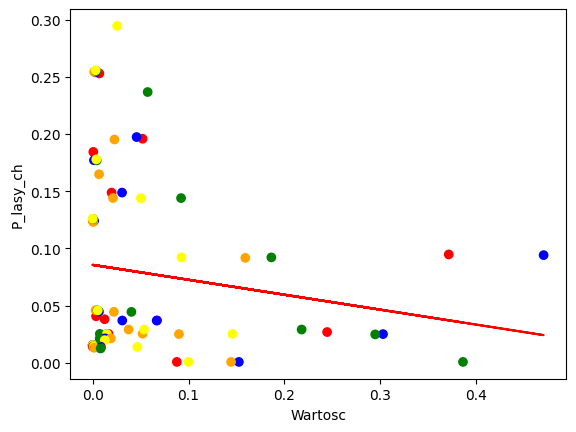

In [79]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Wartosc'], data_norm_vec['P_lasy_ch'])
plt.clf()
plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['P_lasy_ch'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Wartosc']
y = data_norm_vec['P_lasy_ch']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('P_lasy_ch')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\845877124.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Pozary'], c= color_seq, cmap='viridis' )


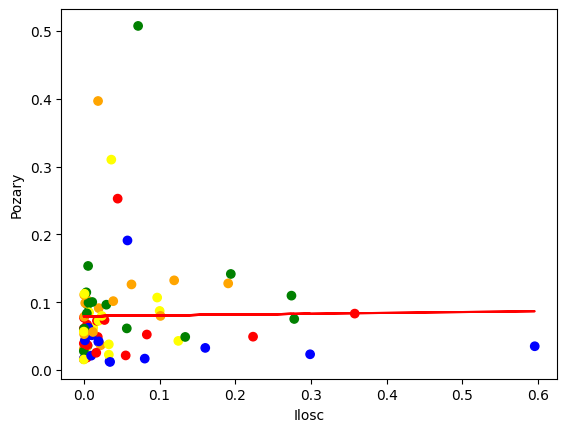

In [80]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Ilosc'], data_norm_vec['Pozary'])
plt.clf()
plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Pozary'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Ilosc']
y = data_norm_vec['Pozary']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Pozary')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\3494949719.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Pozary'], c= color_seq, cmap='viridis' )


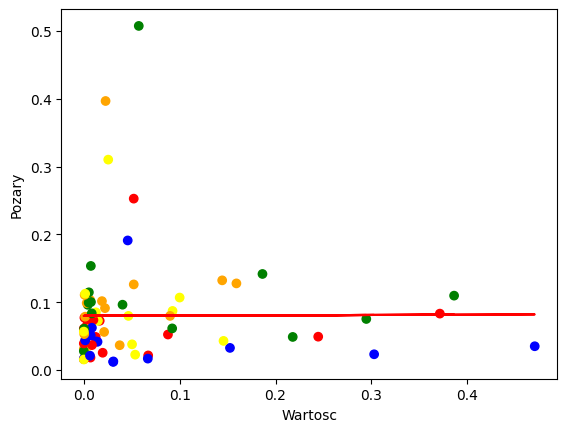

In [81]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Wartosc'], data_norm_vec['Pozary'])
plt.clf()
plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Pozary'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Wartosc']
y = data_norm_vec['Pozary']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Pozary')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\949317870.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Za-pyl'], c= color_seq, cmap='viridis' )


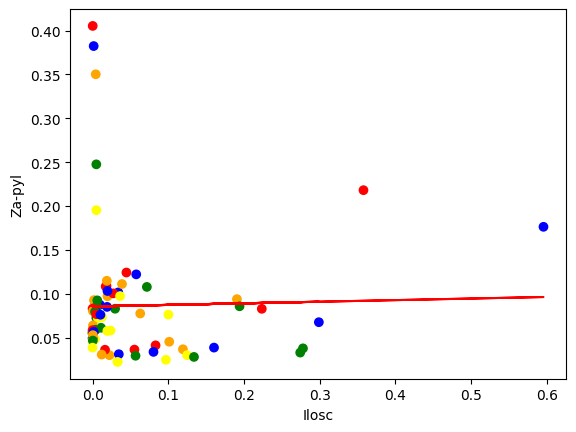

In [82]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Ilosc'], data_norm_vec['Za-pyl'])
plt.clf()
plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Za-pyl'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Ilosc']
y = data_norm_vec['Za-pyl']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Za-pyl')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\1041346948.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Za-pyl'], c= color_seq, cmap='viridis' )


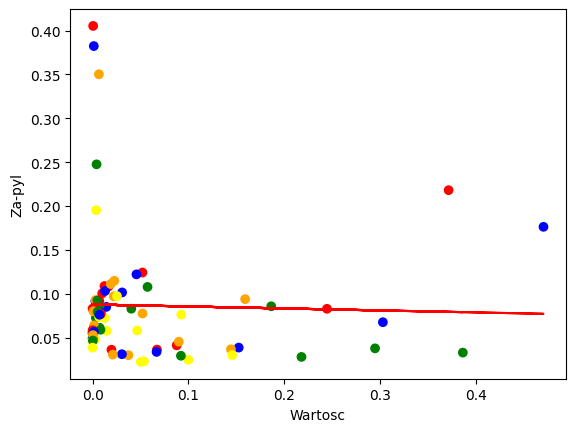

In [83]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Wartosc'], data_norm_vec['Za-pyl'])
plt.clf()
plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Za-pyl'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Wartosc']
y = data_norm_vec['Za-pyl']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Za-pyl')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\2123506106.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Za_gaz'], c= color_seq, cmap='viridis' )


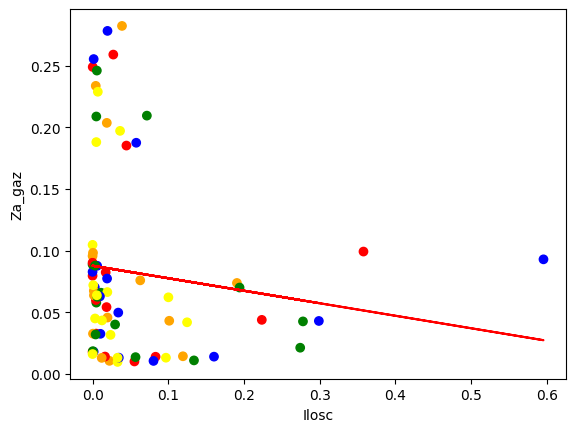

In [85]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Ilosc'], data_norm_vec['Za_gaz'])
plt.clf()
plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Za_gaz'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Ilosc']
y = data_norm_vec['Za_gaz']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Za_gaz')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\3781696239.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Za_gaz'], c= color_seq, cmap='viridis' )


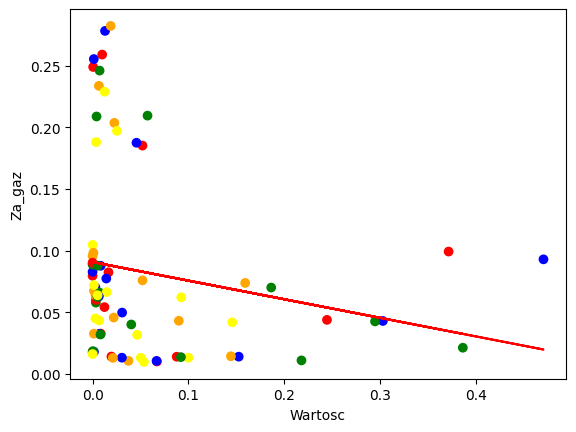

In [86]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Wartosc'], data_norm_vec['Za_gaz'])
plt.clf()
plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Za_gaz'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Wartosc']
y = data_norm_vec['Za_gaz']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Za_gaz')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\3033207106.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Zatrudnienie'], c= color_seq, cmap='viridis' )


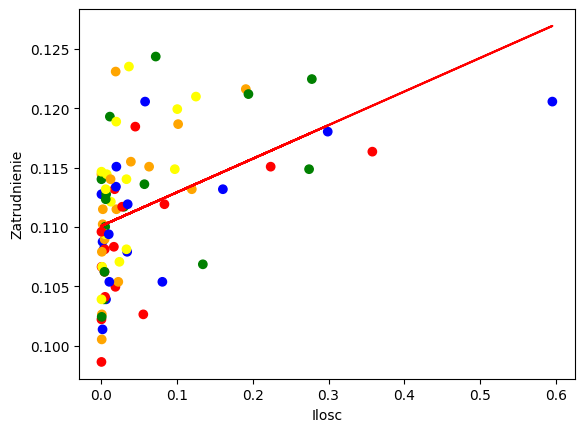

In [87]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Ilosc'], data_norm_vec['Zatrudnienie'])
plt.clf()
plt.scatter(data_norm_vec['Ilosc'], data_norm_vec['Zatrudnienie'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Ilosc']
y = data_norm_vec['Zatrudnienie']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Zatrudnienie')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


C:\Users\ksepk\AppData\Local\Temp\ipykernel_18428\3995019093.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Zatrudnienie'], c= color_seq, cmap='viridis' )


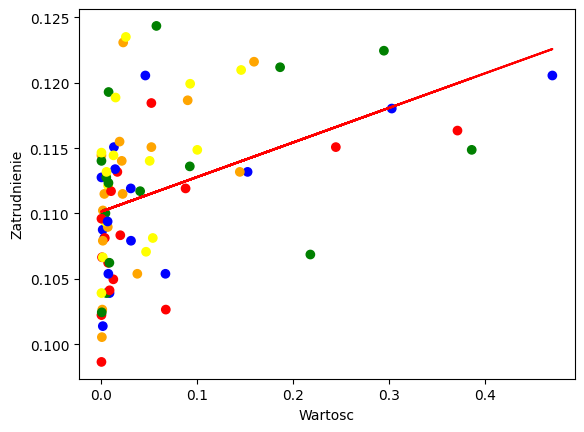

In [88]:
import numpy as np
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (data_norm_vec['Ilosc'].size)
for i in range(int((data_norm_vec['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
np.corrcoef(data_norm_vec['Wartosc'], data_norm_vec['Zatrudnienie'])
plt.clf()
plt.scatter(data_norm_vec['Wartosc'], data_norm_vec['Zatrudnienie'], c= color_seq, cmap='viridis' )
x = data_norm_vec['Wartosc']
y = data_norm_vec['Zatrudnienie']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Zatrudnienie')
plt.show()